<Figure size 600x600 with 0 Axes>

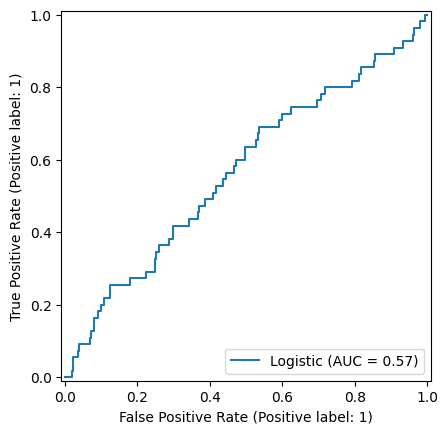

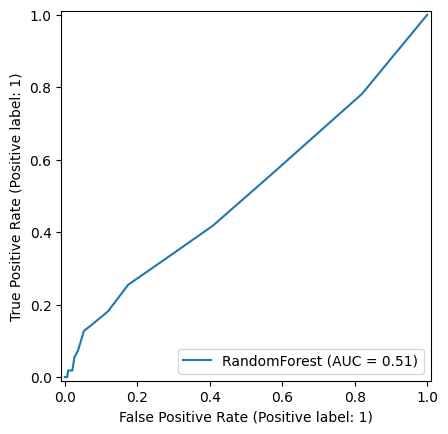

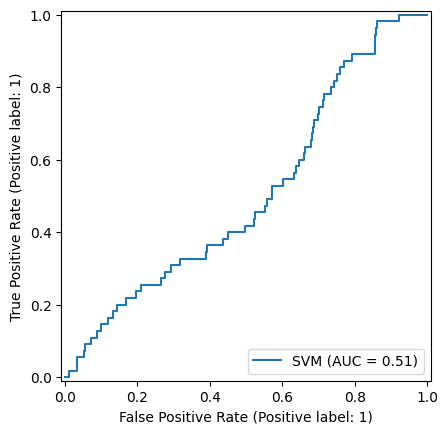

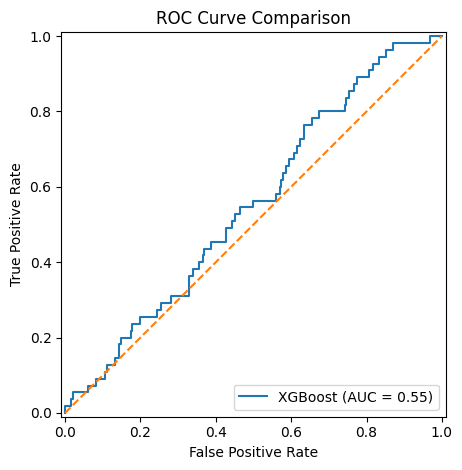


RQ2 Results:

          Model  Accuracy  Precision    Recall        F1       AUC
0      Logistic    0.6505   0.034682  0.436364  0.064257  0.567450
1  RandomForest    0.9725   0.000000  0.000000  0.000000  0.510643
2           SVM    0.7965   0.031915  0.218182  0.055684  0.505670
3       XGBoost    0.9725   0.000000  0.000000  0.000000  0.551802


In [6]:
# RQ2: MODEL COMPARISON 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

# LOAD DATASET

df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')
df = df.dropna()

# DEFINE X and y

y = df['mortality']
X = df.drop(columns=['mortality'])


# PREPROCESSING

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


# SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# MODELS

models = {
    'Logistic': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
    ]),
    
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
    ]),
    
    'SVM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', SVC(probability=True, class_weight='balanced'))
    ]),

    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(eval_metric='logloss'))
    ])
}

# EVALUATION

results = []
plt.figure(figsize=(6,6))

for name, model in models.items():
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    # ROC curve
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name)

    # Append EXACTLY 6 values
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

# ROC diagonal
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()

plt.savefig("rq2_roc_curve.pdf")
plt.show()

# RESULTS TABLE (MATCHED 6 COLUMNS)

results_df = pd.DataFrame(results, columns=[
    'Model','Accuracy','Precision','Recall','F1','AUC'
])

# SAVE
results_df.to_csv("rq2_table.csv", index=False)

print("\nRQ2 Results:\n")
print(results_df)